<a href="https://colab.research.google.com/github/NaomiYatana/Actividad-4.6-Examen/blob/main/C%C3%B3digo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Algoritmo KNN**

Se conoce como algoritmo de aprendizaje perezoso porque no aprende del conjunto de entrenamiento de inmediato, sino que almacena todo el conjunto de datos y realiza los cálculos solo en el momento de la clasificación.KNN funciona utilizando la proximidad y el voto mayoritario para hacer predicciones.

**Fundamentos matemáticos**

KNN utiliza métricas de distancia para identificar al vecino más cercano; estos vecinos se utilizan para tareas de clasificación y regresión. Para identificar al vecino más cercano, utilizamos las siguientes métricas de distancia:

1. Distancia euclidiana
La distancia euclidiana se define como la distancia en línea recta entre dos puntos en un plano o espacio. Se puede imaginar como el camino más corto que recorrerías si fueras directamente de un punto a otro.
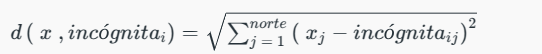

2. Distancia a Manhattan
Esta es la distancia total que recorrerías si solo pudieras moverte a lo largo de líneas horizontales y verticales, como en una cuadrícula o las calles de una ciudad. También se le llama "distancia en taxi" porque un taxi solo puede circular por las calles de una ciudad, que forman una cuadrícula.

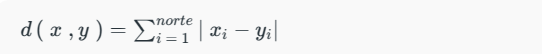

3. Distancia de Minkowski
La distancia de Minkowski es como una familia de distancias, que incluye tanto la distancia euclidiana como la de Manhattan como casos especiales.

Según la fórmula, cuando p=2, se obtiene la misma distancia euclidiana, y cuando p=1, se obtiene la distancia de Manhattan. La distancia de Minkowski es, en esencia, una fórmula flexible que puede representar tanto la distancia euclidiana como la de Manhattan, dependiendo del valor de p.

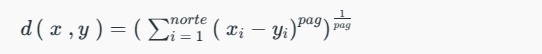






**Descripción formal o narrativa del algoritmo**

KNN es un algoritmo supervisado, no paramétrico y basado en instancias. Se usa para clasificación y regresión. El algoritmo KNN funciona según el principio de similitud, donde predice la etiqueta o el valor de un nuevo punto de datos considerando las etiquetas o los valores de sus K vecinos más cercanos en el conjunto de datos de entrenamiento.

- Paso 1: Seleccionar el valor óptimo de K
K es el número de vecinos más cercanos considerados para la predicción.

- Paso 2: Cálculo de la distancia
Para medir la similitud entre los puntos de datos objetivo y de entrenamiento, se utiliza ampliamente la distancia euclidiana. Esta distancia se calcula entre los puntos de datos del conjunto de datos y el punto objetivo.

- Paso 3: Encontrar a los vecinos más cercanos
Los k puntos de datos con las distancias más pequeñas al punto objetivo son los vecinos más cercanos.

- Paso 4: Votar para la clasificación o tomar el promedio para la regresión.
Cuando se desea clasificar un dato en una categoría, como spam o no spam, el algoritmo KNN examina los K puntos más cercanos en el conjunto de datos. Estos puntos más cercanos se denominan vecinos. A continuación, el algoritmo analiza a qué categoría pertenecen los vecinos y selecciona la que aparece con mayor frecuencia. Esto se conoce como votación por mayoría.
En la regresión, el algoritmo sigue buscando los K puntos más cercanos. Pero en lugar de votar por una clase, como en la clasificación, toma el promedio de los valores de esos K vecinos. Este promedio es el valor predicho para el nuevo punto según el algoritmo.


Pseudocódigo

ALGORITMO KNN_CLASIFICACION(D, k, x_q)

    PARA cada (x_i, y_i) en D HACER

        distancias[i] = distancia_euclidiana(x_q, x_i)

    FIN PARA

    indices_ordenados = ordenar_indices_por_valor(distancias)

    vecinos_cercanos = indices_ordenados[0:k]

    etiquetas_vecinos = [y_i para i en vecinos_cercanos]

    retornar moda(etiquetas_vecinos)
    
FIN ALGORITMO

Código

In [1]:
#Importación de librerías
import numpy as np
from collections import Counter

In [2]:
#Definición de la función de distancia euclidiana
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

In [3]:
#Función de predicción
def knn_predict(training_data, training_labels, test_point, k):
    distances = []
    for i in range(len(training_data)):
        dist = euclidean_distance(test_point, training_data[i])
        distances.append((dist, training_labels[i]))
    distances.sort(key=lambda x: x[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    return Counter(k_nearest_labels).most_common(1)[0][0]

In [4]:
#Datos de entrenamiento, etiquetas y punto de prueba
training_data = [[1, 2], [2, 3], [3, 4], [6, 7], [7, 8]]
training_labels = ['A', 'A', 'A', 'B', 'B']
test_point = [4, 5]
k = 3

In [5]:
#Predicción
prediction = knn_predict(training_data, training_labels, test_point, k)
print(prediction)

A


   KNN desde cero - Demostración con nuevo input

Precisión en conjunto de prueba: 0.80

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.70      0.70      0.70        10
   virginica       0.70      0.70      0.70        10

    accuracy                           0.80        30
   macro avg       0.80      0.80      0.80        30
weighted avg       0.80      0.80      0.80        30


   NUEVO INPUT PROPORCIONADO:
   Características: largo_sépalo=5.8, ancho_sépalo=3.2
   Clase predicha: 1 -> versicolor


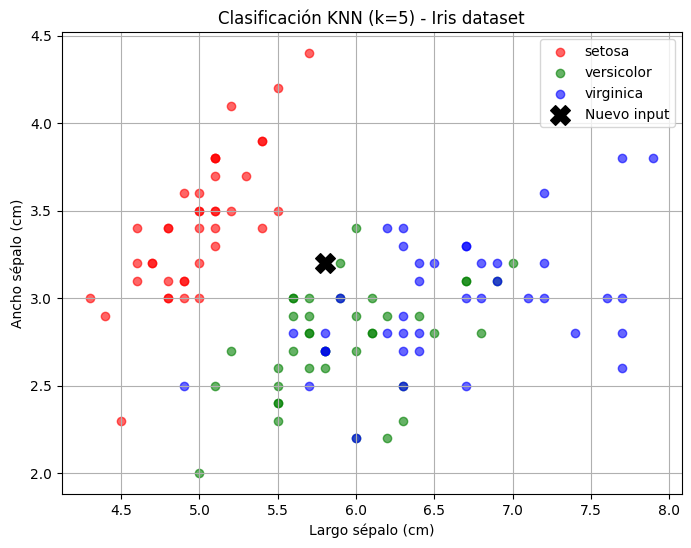

In [6]:
#Importamos las librerías
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

class KNNClassifier:
    """
    Clasificador K-Nearest Neighbors desde cero.

    Parámetros
    ----------
    k : int, default=3
        Número de vecinos a considerar.
    distancia : str, default='euclidiana'
        Tipo de métrica de distancia ('euclidiana' o 'manhattan').
    """

    def __init__(self, k=3, distancia='euclidiana'):
        # Validación de parámetros
        if not isinstance(k, int) or k <= 0:
            raise ValueError("k debe ser un entero positivo")
        if distancia not in ['euclidiana', 'manhattan']:
            raise ValueError("distancia debe ser 'euclidiana' o 'manhattan'")

        self.k = k
        self.distancia = distancia
        self.X_train = None
        self.y_train = None

    def _calcular_distancia(self, a, b):
        """Calcula distancia entre dos vectores según la métrica elegida."""
        if self.distancia == 'euclidiana':
            return np.sqrt(np.sum((a - b) ** 2))
        elif self.distancia == 'manhattan':
            return np.sum(np.abs(a - b))

    def fit(self, X, y):
        """
        Entrena el modelo almacenando los datos de entrenamiento.

        Parámetros
        ----------
        X : array-like, shape (n_muestras, n_características)
            Datos de entrenamiento.
        y : array-like, shape (n_muestras,)
            Etiquetas objetivo.
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def _predecir_uno(self, x):
        """Predice la etiqueta para una sola muestra."""
        # Calcular distancias a todos los puntos de entrenamiento
        distancias = [self._calcular_distancia(x, x_train) for x_train in self.X_train]

        # Obtener índices de los k vecinos más cercanos
        k_indices = np.argsort(distancias)[:self.k]

        # Obtener etiquetas de esos vecinos
        k_etiquetas = self.y_train[k_indices]

        # Voto mayoritario
        etiqueta_comun = Counter(k_etiquetas).most_common(1)[0][0]
        return etiqueta_comun

    def predict(self, X):
        """
        Predice las etiquetas para un conjunto de muestras.

        Parámetros
        ----------
        X : array-like, shape (n_muestras, n_características)
            Datos a predecir.

        Retorna
        -------
        y_pred : array, shape (n_muestras,)
            Etiquetas predichas.
        """
        X = np.array(X)
        predicciones = [self._predecir_uno(x) for x in X]
        return np.array(predicciones)


# ======================
# EJEMPLO DE USO CON NUEVO INPUT (EXAMEN)
# ======================

def ejemplo_con_nuevo_input():
    """
    Aplica el modelo KNN con datos sintéticos y un nuevo input de prueba.
    """
    print("=" * 60)
    print("   KNN desde cero - Demostración con nuevo input")
    print("=" * 60)

    # 1. Cargar dataset de ejemplo (Iris, pero solo 2 características para visualizar)
    iris = load_iris()
    X = iris.data[:, :2]  # Usamos solo largo y ancho del sépalo
    y = iris.target       # 3 clases de flores

    # 2. Dividir en entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 3. Entrenar modelo KNN con k=5
    knn = KNNClassifier(k=5, distancia='euclidiana')
    knn.fit(X_train, y_train)

    # 4. Evaluar en test
    y_pred = knn.predict(X_test)
    precision = accuracy_score(y_test, y_pred)
    print(f"\nPrecisión en conjunto de prueba: {precision:.2f}")
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))

    # 5. NUEVO INPUT (simula un dato que el profesor proporciona en el examen)
    # Supongamos un nuevo iris con:
    # Largo de sépalo = 5.8, Ancho de sépalo = 3.2
    nuevo_ejemplo = np.array([[5.8, 3.2]])

    # Predicción
    clase_predicha = knn.predict(nuevo_ejemplo)
    nombre_flor = iris.target_names[clase_predicha[0]]

    print("\n" + "=" * 60)
    print("   NUEVO INPUT PROPORCIONADO:")
    print(f"   Características: largo_sépalo=5.8, ancho_sépalo=3.2")
    print(f"   Clase predicha: {clase_predicha[0]} -> {nombre_flor}")
    print("=" * 60)

    # 6. Visualización (opcional)
    plt.figure(figsize=(8, 6))
    colores = ['red', 'green', 'blue']
    for i, clase in enumerate(np.unique(y)):
        plt.scatter(X_train[y_train == clase, 0],
                   X_train[y_train == clase, 1],
                   c=colores[i], label=iris.target_names[clase], alpha=0.6)

    # Marcar el nuevo input
    plt.scatter(nuevo_ejemplo[0, 0], nuevo_ejemplo[0, 1],
               c='black', marker='X', s=200, label='Nuevo input')
    plt.xlabel('Largo sépalo (cm)')
    plt.ylabel('Ancho sépalo (cm)')
    plt.title('Clasificación KNN (k=5) - Iris dataset')
    plt.legend()
    plt.grid(True)
    plt.show()

    return knn, nuevo_ejemplo, clase_predicha

# Ejecutar el ejemplo
if __name__ == "__main__":
    modelo, input_nuevo, prediccion = ejemplo_con_nuevo_input()